# MTG Set Release Price Research

This notebook answers: **when, after a new set releases, do card prices reach their lowest point?**

Scope: regular expansion sets, 2021–present, nonfoil only.

---

## Part 1 — Data Setup

In [ ]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
PARQUET_PATH = DATA_DIR / "set_price_window.parquet"
REFRESH = False  # set True to re-query the DB

DB_CONFIG = dict(
    host="localhost",
    port=5433,
    dbname="automana",
    user="automana_admin",
    password=os.environ.get("AUTOMANA_DB_PASSWORD", ""),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

**Cell below:** Connect to the local PostgreSQL DB and extract price data for all expansion sets within the first 150 days after release. Result is cached to `data/set_price_window.parquet` so subsequent runs are instant.

> Set `REFRESH = True` to re-query after new sets are ingested.

In [ ]:
SQL = """
SELECT
    s.set_code,
    s.set_name,
    s.released_at,
    r.rarity_name,
    cv.card_version_id,
    ppd.price_date,
    (ppd.price_date - s.released_at)::int AS days_since_release,
    ppd.list_low_cents,
    ppd.list_avg_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st  ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND s.released_at BETWEEN '2021-01-01' AND CURRENT_DATE
  AND ppd.price_date >= s.released_at
  AND ppd.price_date <= s.released_at + INTERVAL '150 days'
  AND ppd.finish_id = 1
  AND ppd.list_low_cents IS NOT NULL
  AND ppd.list_low_cents > 0
  AND r.rarity_name IN ('common', 'uncommon', 'rare', 'mythic')
"""

def query_to_df(sql, date_cols=("released_at", "price_date")):
    """Execute SQL via psycopg2 cursor directly — avoids pandas DBAPI2 silent failures."""
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    df = pd.DataFrame(rows, columns=cols)
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

if REFRESH or not PARQUET_PATH.exists():
    print("Querying DB…")
    raw = query_to_df(SQL)
    raw.to_parquet(PARQUET_PATH, index=False)
    print(f"Saved {len(raw):,} rows → {PARQUET_PATH}")
else:
    raw = pd.read_parquet(PARQUET_PATH)
    assert len(raw) > 0, "Parquet loaded empty — delete it and re-run with REFRESH=True"

print(raw.head(3))

**Cell below:** Sanity-check coverage — how many sets, cards per rarity, and date range.

In [9]:
print("Sets in data:", raw["set_code"].nunique())
print("\nRarity breakdown:\n", raw["rarity_name"].value_counts())
print("\nDays range:", raw["days_since_release"].min(), "→", raw["days_since_release"].max())
print("Null list_low_cents:", raw["list_low_cents"].isna().sum())

sets_summary = (
    raw.groupby(["set_code", "set_name", "released_at"])
    .agg(cards=("card_version_id", "nunique"), rows=("list_low_cents", "count"))
    .sort_values("released_at")
)
display(sets_summary)

Sets in data: 25

Rarity breakdown:
 rarity_name
rare        417424
common      379558
uncommon    339569
mythic      152076
Name: count, dtype: int64

Days range: 0 → 150
Null list_low_cents: 0


,,,cards,rows
set_code,set_name,released_at,,
khm,Kaldheim,2021-02-05,402,22914
stx,Strixhaven: School of Mages,2021-04-23,380,50460
afr,Adventures in the Forgotten Realms,2021-07-23,400,60386
mid,Innistrad: Midnight Hunt,2021-09-24,389,58350
vow,Innistrad: Crimson Vow,2021-11-19,405,60293
neo,Kamigawa: Neon Dynasty,2022-02-18,492,73312
snc,Streets of New Capenna,2022-04-29,399,59040
dmu,Dominaria United,2022-09-09,391,57978
bro,The Brothers' War,2022-11-18,382,57663


---

## Part 2 — Set-Level Price Trajectory

We aggregate prices to the *(set, rarity, day)* level, normalize to day-0 = 100, smooth noise, and compute the rate of change to find when prices stop falling.

In [10]:
# Median list_low_cents across all cards in the group for each day
daily = (
    raw.groupby(["set_code", "set_name", "released_at", "rarity_name", "days_since_release"])
    .agg(
        median_cents=("list_low_cents", "median"),
        card_count=("card_version_id", "nunique"),
    )
    .reset_index()
)

# Drop groups with fewer than 5 distinct cards (thin markets / promos slipping through)
daily = daily[daily["card_count"] >= 5].copy()

print(f"Rows after aggregation: {len(daily):,}")
print(daily.head(10))

Rows after aggregation: 13,329
  set_code                            set_name released_at rarity_name  \
0      afr  Adventures in the Forgotten Realms  2021-07-23      common   
1      afr  Adventures in the Forgotten Realms  2021-07-23      common   
2      afr  Adventures in the Forgotten Realms  2021-07-23      common   
3      afr  Adventures in the Forgotten Realms  2021-07-23      common   
4      afr  Adventures in the Forgotten Realms  2021-07-23      common   
5      afr  Adventures in the Forgotten Realms  2021-07-23      common   
6      afr  Adventures in the Forgotten Realms  2021-07-23      common   
7      afr  Adventures in the Forgotten Realms  2021-07-23      common   
8      afr  Adventures in the Forgotten Realms  2021-07-23      common   
9      afr  Adventures in the Forgotten Realms  2021-07-23      common   

   days_since_release  median_cents  card_count  
0                   0           4.0         139  
1                   1           4.0         139  
2   

**Cell below:** Aggregate `list_low_cents` to a daily median per *(set, rarity, day)*. Drop groups with fewer than 5 distinct cards to filter thin markets.

In [11]:
def day0_price(group):
    anchor = group[group["days_since_release"] <= 7].nsmallest(1, "days_since_release")
    if anchor.empty:
        return pd.Series(np.nan, index=group.index)
    base = anchor["median_cents"].values[0]
    if base == 0:
        return pd.Series(np.nan, index=group.index)
    return (group["median_cents"] / base) * 100

daily["price_index"] = (
    daily.groupby(["set_code", "rarity_name"], group_keys=False)
    .apply(day0_price)
)

# Drop series that couldn't be anchored
daily = daily.dropna(subset=["price_index"])
print(f"Rows after normalisation: {len(daily):,}")
print(daily[daily["days_since_release"] == 0][["set_code", "rarity_name", "price_index"]].head(8))

Rows after normalisation: 12,565
     set_code rarity_name  price_index
0         afr      common        100.0
151       afr      mythic        100.0
302       afr        rare        100.0
453       afr    uncommon        100.0
604       big      mythic        100.0
755       blb      common        100.0
906       blb      mythic        100.0
1057      blb        rare        100.0


**Cell below:** Normalize each *(set, rarity)* series to an index of 100 at day 0 (first available price ≤ day 7). This makes curves comparable across sets regardless of absolute price level.

In [12]:
daily = daily.sort_values(["set_code", "rarity_name", "days_since_release"])

# Reindex each group to the full 0-150 calendar-day range before rolling.
# Uses an explicit loop to avoid pandas 2.2+ include_groups deprecation in apply.
groups = []
for (set_code, set_name, released_at, rarity_name), g in daily.groupby(
    ["set_code", "set_name", "released_at", "rarity_name"], sort=False
):
    g_idx = g.set_index("days_since_release").reindex(range(0, 151))
    g_idx["smoothed"] = g_idx["price_index"].rolling(window=7, min_periods=3, center=True).median()
    g_idx["roc_14d"] = g_idx["smoothed"].pct_change(periods=14) * 100
    # Restore group key columns lost during reindex
    g_idx["set_code"] = set_code
    g_idx["set_name"] = set_name
    g_idx["released_at"] = released_at
    g_idx["rarity_name"] = rarity_name
    groups.append(g_idx.reset_index())

daily = (
    pd.concat(groups)
    .dropna(subset=["median_cents"])
    .reset_index(drop=True)
)

# Spot-check: one set, one rarity
sample = daily[(daily["set_code"] == "dmu") & (daily["rarity_name"] == "rare")]
print(sample[["days_since_release", "price_index", "smoothed", "roc_14d"]].head(15))

      days_since_release  price_index   smoothed    roc_14d
2865                   0   100.000000  66.666667        NaN
2866                   1    66.666667  65.000000        NaN
2867                   2    63.333333  63.333333        NaN
2868                   4    59.333333  55.666667        NaN
2869                   5    52.000000  51.333333        NaN
2870                   6    50.666667  48.666667        NaN
2871                   7    46.666667  48.666667        NaN
2872                   8    34.666667  44.000000        NaN
2873                   9    41.333333  40.000000        NaN
2874                  11    38.666667  35.666667        NaN
2875                  12    36.666667  35.666667        NaN
2876                  13    34.666667  34.000000        NaN
2877                  14    33.333333  33.333333 -50.000000
2878                  15    32.666667  33.333333 -48.717949
2879                  16    32.666667  32.666667 -48.421053


**Cell below:** Reindex each series to the full 0–150 calendar-day range, then apply:
- **7-day rolling median** on `price_index` → `smoothed` (removes weekly data-update noise)
- **14-day rolling % change** on `smoothed` → `roc_14d` (measures how fast prices are moving)

In [13]:
print(daily[daily["set_code"] == "dmu"][
    ["days_since_release", "rarity_name", "smoothed", "roc_14d"]
].dropna().head(20))

      days_since_release rarity_name  smoothed    roc_14d
2579                  14      common      20.0 -80.000000
2580                  15      common      20.0 -77.777778
2581                  16      common      20.0 -75.000000
2582                  17      common      20.0 -66.666667
2583                  18      common      20.0 -50.000000
2584                  19      common      20.0 -50.000000
2585                  20      common      20.0 -33.333333
2586                  21      common      20.0 -33.333333
2587                  22      common      20.0   0.000000
2588                  23      common      20.0   0.000000
2589                  24      common      20.0   0.000000
2590                  25      common      20.0   0.000000
2591                  26      common      20.0   0.000000
2592                  27      common      20.0   0.000000
2593                  28      common      20.0   0.000000
2594                  29      common      20.0   0.000000
2595          

**Cell below:** Spot-check the smoothed curves and rate-of-change for one set (Dominaria United).

In [14]:
THRESHOLD = -5.0    # ROC above this = "stabilized"
MIN_DECLINE_DAYS = 7

def find_inflection(group):
    g = group.dropna(subset=["roc_14d"]).sort_values("days_since_release")
    if g.empty:
        return np.nan

    streak_start_day = None
    entered_decline = False
    for _, row in g.iterrows():
        if row["roc_14d"] < THRESHOLD:
            if streak_start_day is None:
                streak_start_day = row["days_since_release"]
            if (row["days_since_release"] - streak_start_day) >= MIN_DECLINE_DAYS:
                entered_decline = True
        else:
            if entered_decline:
                return row["days_since_release"]
            streak_start_day = None

    # Fallback: day of minimum smoothed index
    return g.loc[g["smoothed"].idxmin(), "days_since_release"]

inflections = (
    daily.groupby(["set_code", "set_name", "released_at", "rarity_name"])
    .apply(find_inflection, include_groups=False)
    .reset_index(name="inflection_day")
    .dropna(subset=["inflection_day"])
)
inflections["inflection_day"] = inflections["inflection_day"].astype(int)

print(inflections.groupby("rarity_name")["inflection_day"].describe().round(1))

             count  mean   std   min   25%   50%   75%    max
rarity_name                                                  
common        21.0  17.3   7.3  14.0  14.0  14.0  14.0   43.0
mythic        22.0  51.4  13.7  26.0  41.0  53.0  58.8   77.0
rare          21.0  44.9  19.1  27.0  31.0  41.0  50.0  107.0
uncommon      21.0  28.1  13.1  14.0  23.0  26.0  30.0   70.0


**Cell below:** Detect the **inflection day** per *(set, rarity)* — the first day where the 14-day rate of change rises above −5% after at least 7 consecutive calendar days of stronger decline. This marks the transition from *actively falling* to *stabilizing*.

Fallback: if no clear inflection is found within 150 days, the day of the raw minimum is used.

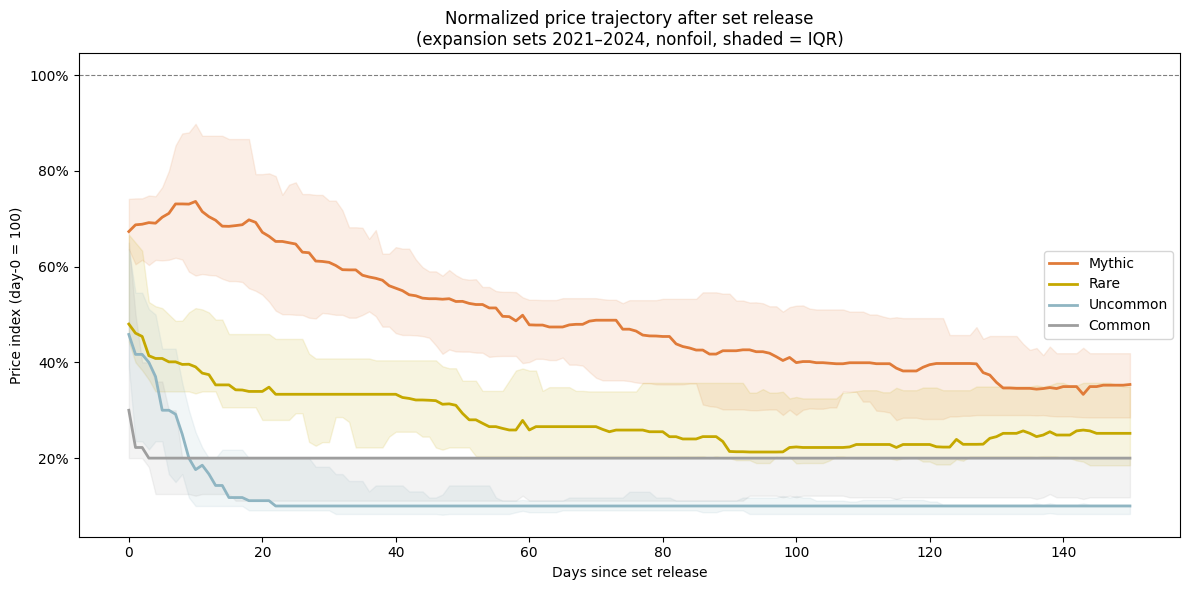

In [15]:
FOCUS_RARITIES = ["mythic", "rare"]  # Part 3 shows only rare/mythic

RARITY_ORDER = ["mythic", "rare", "uncommon", "common"]
RARITY_COLORS = {"mythic": "#e07b39", "rare": "#c5a800", "uncommon": "#8fb5c2", "common": "#9e9e9e"}

fig, ax = plt.subplots(figsize=(12, 6))

for rarity in FOCUS_RARITIES:
    sub = daily[daily["rarity_name"] == rarity]
    agg = sub.groupby("days_since_release")["smoothed"].agg(
        median="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    agg = agg[agg.index <= 150]
    color = RARITY_COLORS[rarity]
    ax.plot(agg.index, agg["median"], label=rarity.capitalize(), color=color, linewidth=2)
    ax.fill_between(agg.index, agg["p25"], agg["p75"], color=color, alpha=0.12)

ax.axhline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Days since set release")
ax.set_ylabel("Price index (day-0 = 100)")
ax.set_title("Normalized price trajectory after set release\n(expansion sets 2021\u20132024, nonfoil, shaded = IQR)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
plt.tight_layout()
plt.savefig(DATA_DIR / "fig1_avg_price_curve.png", dpi=150)
plt.show()

---

## Part 3 — Figures

### Figure 1 — Average normalized price curve by rarity

Median price trajectory across all sets, per rarity. Shaded band = interquartile range.

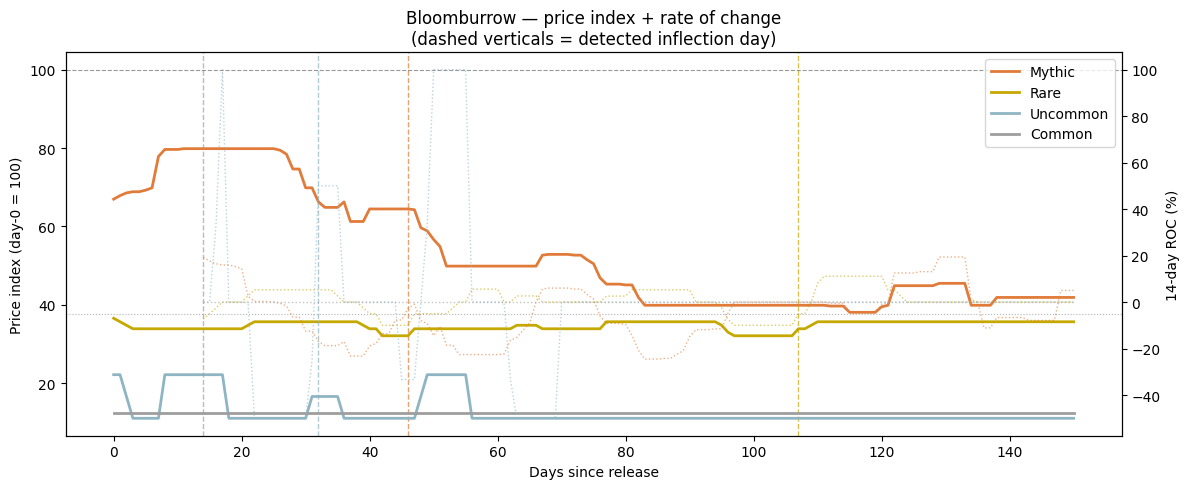

In [16]:
EXAMPLE_SET = "blb"   # Bloomburrow — change to any set_code in the data

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

for rarity in FOCUS_RARITIES:
    sub = daily[(daily["set_code"] == EXAMPLE_SET) & (daily["rarity_name"] == rarity)].sort_values("days_since_release")
    if sub.empty:
        continue
    color = RARITY_COLORS[rarity]
    ax1.plot(sub["days_since_release"], sub["smoothed"], color=color, linewidth=2, label=rarity.capitalize())
    ax2.plot(sub["days_since_release"], sub["roc_14d"], color=color, linewidth=1, linestyle=":", alpha=0.6)

    infl = inflections[(inflections["set_code"] == EXAMPLE_SET) & (inflections["rarity_name"] == rarity)]
    if not infl.empty:
        day = infl["inflection_day"].values[0]
        ax1.axvline(day, color=color, linestyle="--", linewidth=1, alpha=0.7)

ax1.axhline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
ax2.axhline(-5, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax1.set_xlabel("Days since release")
ax1.set_ylabel("Price index (day-0 = 100)")
ax2.set_ylabel("14-day ROC (%)")
ax1.legend(loc="upper right")

set_rows = daily[daily["set_code"] == EXAMPLE_SET]
if set_rows.empty:
    raise ValueError(f"EXAMPLE_SET '{EXAMPLE_SET}' not found in daily — check card_count filter or parquet")
set_name = set_rows["set_name"].iloc[0]
ax1.set_title(f"{set_name} — price index + rate of change\n(dashed verticals = detected inflection day)")
plt.tight_layout()
plt.savefig(DATA_DIR / f"fig2_roc_{EXAMPLE_SET}.png", dpi=150)
plt.show()

### Figure 2 — Single-set example: price index + rate of change

Shows smoothed price index (left axis) and 14-day ROC (right axis, dotted) for one set. Dashed verticals = detected inflection day per rarity.

> Change `EXAMPLE_SET` to any set code in the data.

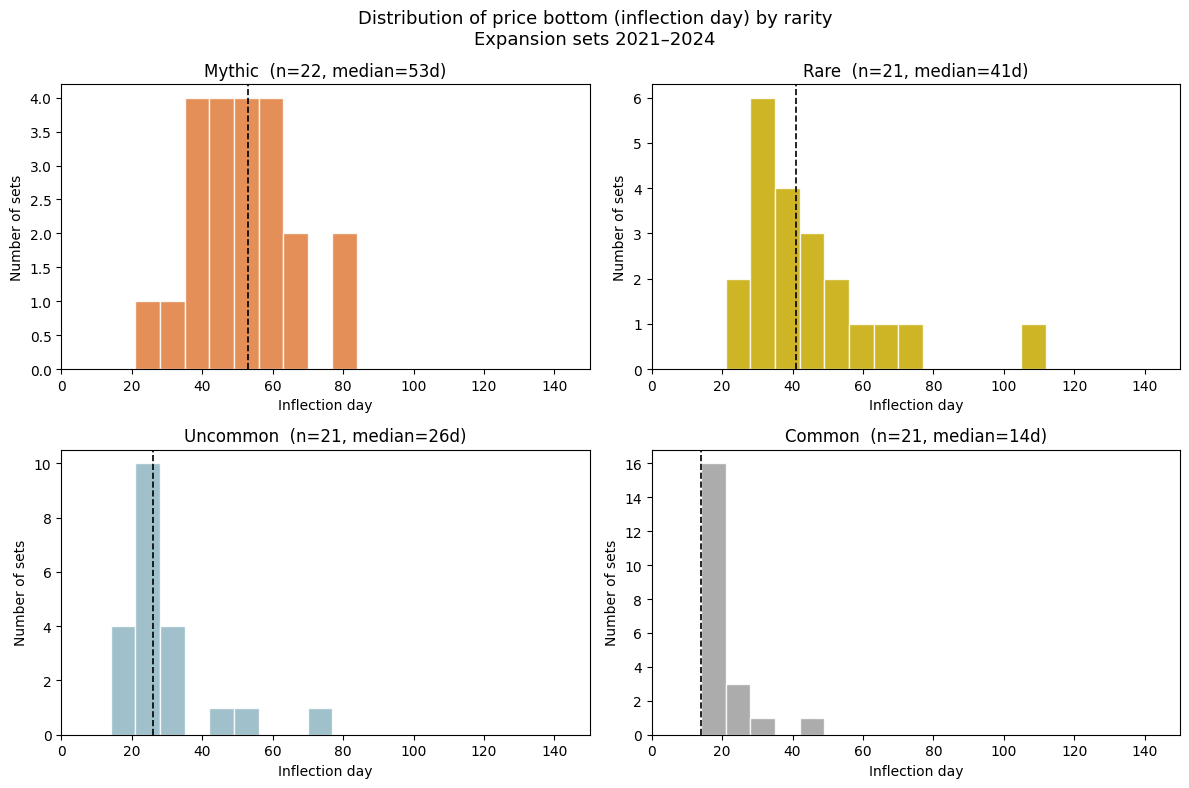

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
axes = axes.flatten()

for i, rarity in enumerate(FOCUS_RARITIES):
    ax = axes[i]
    sub = inflections[inflections["rarity_name"] == rarity]["inflection_day"]
    if sub.empty:
        continue
    ax.hist(sub, bins=range(0, 155, 7), color=RARITY_COLORS[rarity], edgecolor="white", alpha=0.85)
    median_day = int(sub.median())
    ax.axvline(median_day, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"{rarity.capitalize()}  (n={len(sub)}, median={median_day}d)")
    ax.set_xlabel("Inflection day")
    ax.set_ylabel("Number of sets")
    ax.set_xlim(0, 150)

fig.suptitle("Distribution of price bottom (inflection day) by rarity\nExpansion sets 2021\u20132024", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig3_inflection_distribution.png", dpi=150)
plt.show()

### Figure 3 — Distribution of inflection days by rarity

Histogram of *when* prices bottom out, across all sets. Dashed vertical = median.

In [18]:
summary = (
    inflections.groupby("rarity_name")["inflection_day"]
    .agg(
        sets="count",
        median="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        min="min",
        max="max",
    )
    .loc[FOCUS_RARITIES]
    .round(1)
)
summary.index.name = "Rarity"
summary.columns = ["Sets", "Median day", "25th pct", "75th pct", "Min", "Max"]
display(summary)

print("\nConclusion:")
for rarity in FOCUS_RARITIES:
    row = summary.loc[rarity]
    print(f"  {rarity.capitalize():10s} → prices bottom around day {int(row['Median day'])} "
          f"(IQR {int(row['25th pct'])}–{int(row['75th pct'])})")

,Sets,Median day,25th pct,75th pct,Min,Max
Rarity,,,,,,
mythic,22,53.0,41.0,58.8,26,77
rare,21,41.0,31.0,50.0,27,107
uncommon,21,26.0,23.0,30.0,14,70
common,21,14.0,14.0,14.0,14,43



Conclusion:
  Mythic     → prices bottom around day 53 (IQR 41–58)
  Rare       → prices bottom around day 41 (IQR 31–50)
  Uncommon   → prices bottom around day 26 (IQR 23–30)
  Common     → prices bottom around day 14 (IQR 14–14)


### Summary table — median bottom day per rarity

In [26]:
# --- Card-level analysis ---
# Normalize each card to day-0 = 100, smooth with 7-day rolling median.
# Base = first available price within the first week.

card_daily = (
    raw.groupby(["set_code", "rarity_name", "card_version_id", "days_since_release"])
    ["list_low_cents"]
    .median()
    .reset_index(name="daily_cents")
)

# Day-0 anchor per card
day0 = (
    card_daily[card_daily["days_since_release"] <= 7]
    .sort_values("days_since_release")
    .groupby(["set_code", "card_version_id"])
    .first()
    .reset_index()[["set_code", "card_version_id", "daily_cents"]]
    .rename(columns={"daily_cents": "base_cents"})
)
card_daily = card_daily.merge(day0, on=["set_code", "card_version_id"])
card_daily = card_daily[(card_daily["base_cents"] > 0)].copy()
card_daily["card_index"] = card_daily["daily_cents"] / card_daily["base_cents"] * 100

# Smooth + reindex to calendar days (same approach as set-level pipeline)
groups = []
for (set_code, rarity_name, card_id), g in card_daily.groupby(
    ["set_code", "rarity_name", "card_version_id"], sort=False
):
    g_idx = g.set_index("days_since_release").reindex(range(0, 151))
    g_idx["smoothed_card"] = g_idx["card_index"].rolling(7, min_periods=3, center=True).median()
    g_idx["set_code"] = set_code
    g_idx["rarity_name"] = rarity_name
    g_idx["card_version_id"] = card_id
    g_idx["base_cents"] = g["base_cents"].iloc[0]
    groups.append(g_idx.reset_index())

card_curves = (
    pd.concat(groups, ignore_index=True)
    .dropna(subset=["daily_cents"])
)
print(f"Unique cards: {card_curves['card_version_id'].nunique():,}")
print(card_curves[["set_code", "rarity_name", "days_since_release", "card_index", "smoothed_card"]].head(8))


Unique cards: 8,081
  set_code rarity_name  days_since_release  card_index  smoothed_card
0      afr      common                   0       100.0           62.5
1      afr      common                   1       100.0           25.0
2      afr      common                   2        25.0           25.0
3      afr      common                   3        25.0           25.0
4      afr      common                   4        25.0           25.0
5      afr      common                   5        25.0           25.0
6      afr      common                   6        25.0           25.0
7      afr      common                   7        25.0           25.0


---

## Part 4 — Card-Level Analysis

Where the set-level analysis shows *aggregate* trends, this section looks at **individual cards** — how their prices evolve, which fraction gain value, and when they peak.

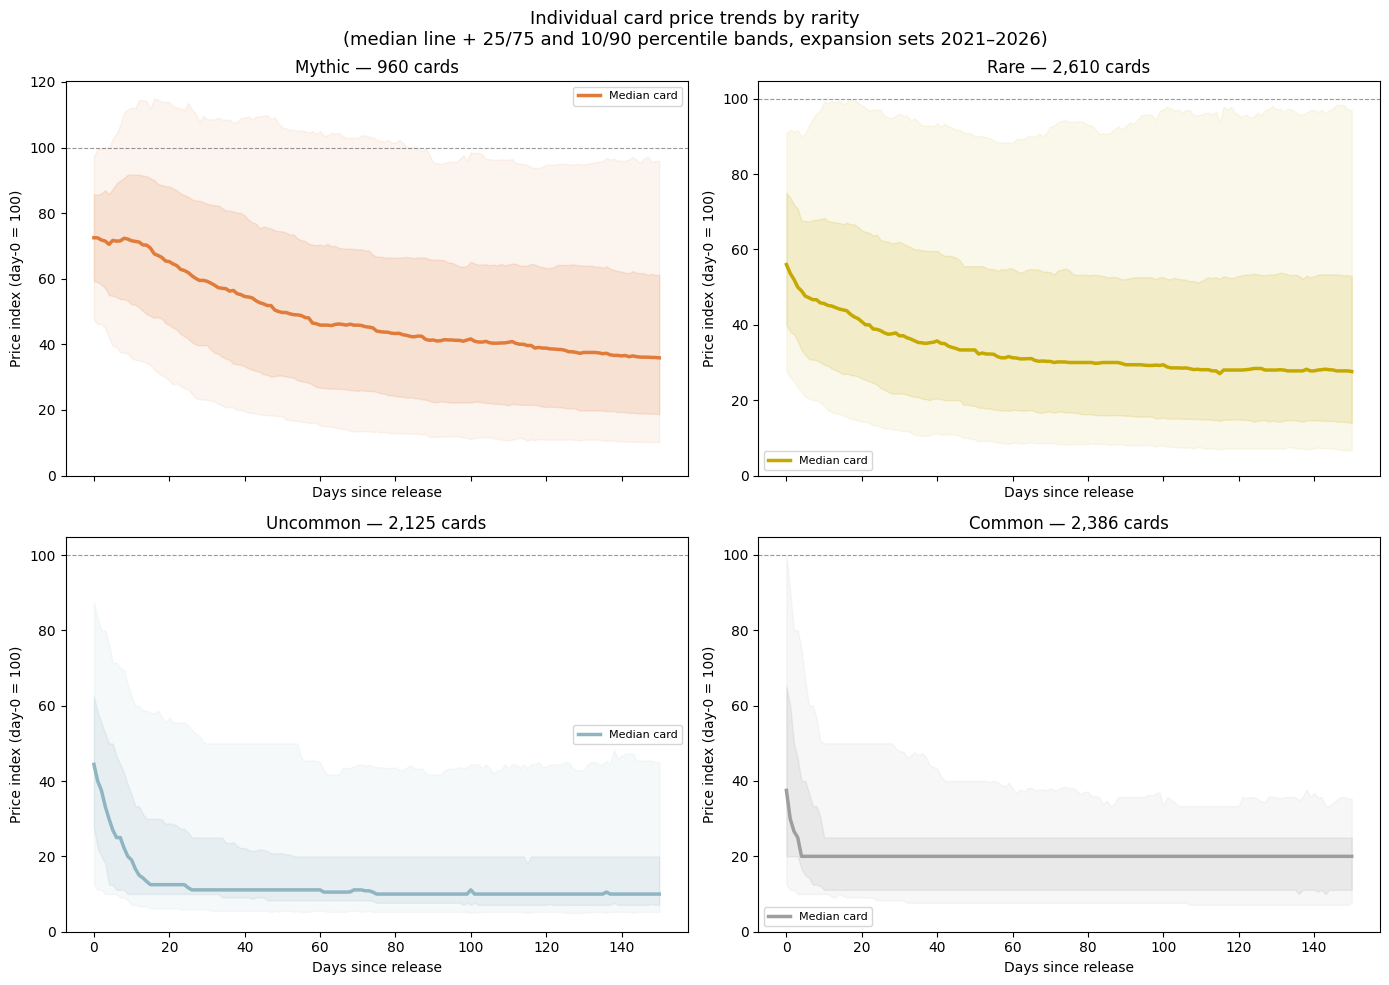

In [27]:
PERCENTILES = [10, 25, 50, 75, 90]
PCT_COLORS  = ["#d62728", "#ff7f0e", "#2ca02c", "#ff7f0e", "#d62728"]
PCT_ALPHAS  = [0.08, 0.12, 1.0, 0.12, 0.08]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, rarity in enumerate(RARITY_ORDER):
    ax = axes[i]
    sub = card_curves[card_curves["rarity_name"] == rarity]
    agg = sub.groupby("days_since_release")["smoothed_card"].describe(
        percentiles=[p / 100 for p in PERCENTILES]
    )
    pct_cols = [f"{p}%" for p in PERCENTILES]

    ax.axhline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

    # Shaded bands between percentiles
    ax.fill_between(agg.index, agg["10%"], agg["90%"],
                    color=RARITY_COLORS[rarity], alpha=0.08)
    ax.fill_between(agg.index, agg["25%"], agg["75%"],
                    color=RARITY_COLORS[rarity], alpha=0.15)
    # Median line
    ax.plot(agg.index, agg["50%"], color=RARITY_COLORS[rarity],
            linewidth=2.5, label="Median card")

    ax.set_title(f"{rarity.capitalize()} — {sub['card_version_id'].nunique():,} cards")
    ax.set_ylabel("Price index (day-0 = 100)")
    ax.set_xlabel("Days since release")
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)

fig.suptitle(
    "Individual card price trends by rarity\n"
    "(median line + 25/75 and 10/90 percentile bands, expansion sets 2021–2026)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig6_card_trends_per_rarity.png", dpi=150)
plt.show()


**Cell below:** Normalize each card to day-0 = 100 and apply a 7-day rolling median. Produces one smoothed price curve per card version.

> This step is compute-heavy — give it a minute on first run.

In [28]:
# Peak day = day of maximum smoothed price per card (within the 150-day window).
# We also capture the peak magnitude: how much above day-0 did it spike?

peaks = (
    card_curves.dropna(subset=["smoothed_card"])
    .groupby(["set_code", "rarity_name", "card_version_id", "base_cents"])
    .apply(
        lambda g: pd.Series({
            "peak_day":   g.loc[g["smoothed_card"].idxmax(), "days_since_release"],
            "peak_index": g["smoothed_card"].max(),        # 100 = no gain
            "final_index": g.loc[g["days_since_release"] == g["days_since_release"].max(),
                                  "smoothed_card"].values[-1],
        }),
        include_groups=False,
    )
    .reset_index()
)

# Flag cards that peaked above their day-0 price (peak_index > 105 = >5% gain)
peaks["peaked"] = peaks["peak_index"] > 105

print(peaks.groupby("rarity_name").agg(
    cards=("card_version_id", "count"),
    pct_peaked=("peaked", lambda x: f"{x.mean()*100:.0f}%"),
    median_peak_day=("peak_day", "median"),
    median_peak_gain=("peak_index", lambda x: f"{x.median():.0f}"),
).loc[RARITY_ORDER])


             cards pct_peaked  median_peak_day median_peak_gain
rarity_name                                                    
mythic         960        24%              6.0               83
rare          2610        16%              1.0               66
uncommon      2125         6%              0.0               48
common        2386         3%              0.0               40


### Figure 6 — Card price distribution evolution by rarity

Instead of plotting thousands of individual lines, we show **percentile bands** at each day: median (line), 25th–75th (inner band), 10th–90th (outer band). Reveals how spread out card values are and how quickly the distribution shifts.

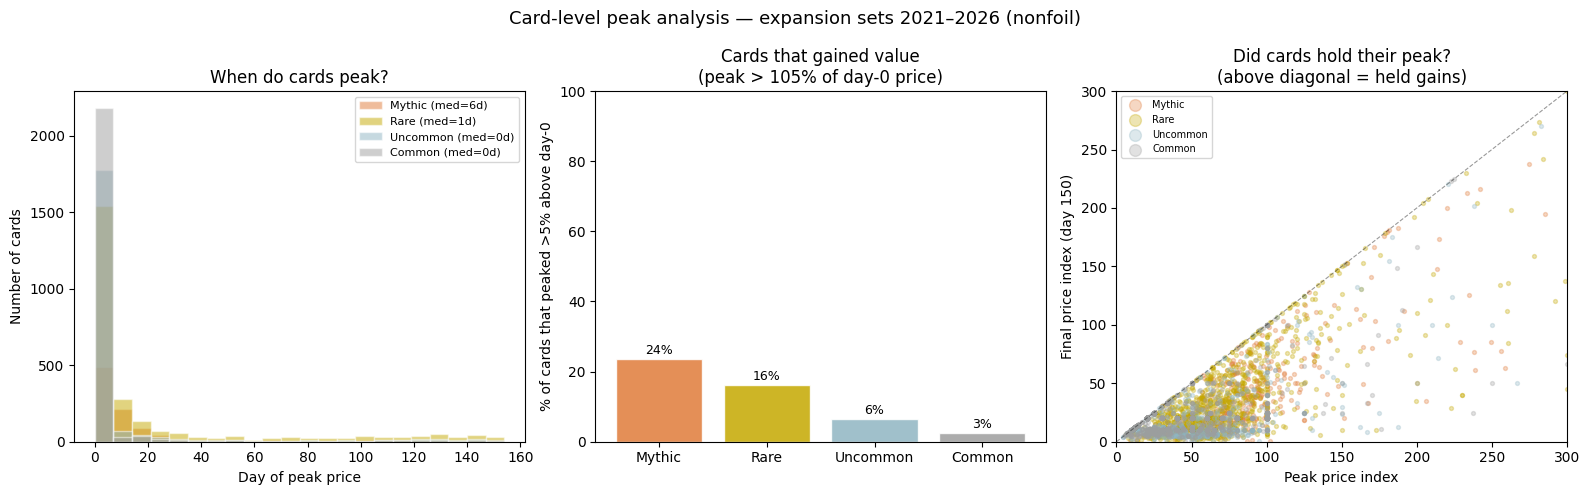


--- Peak detection methodology ---
A card's peak = day of maximum 7-day smoothed price index within the 150-day window.
Signals that a card peaked and held value: peak_index > 105 AND final_index > 90% of peak_index.
Signals a spike-and-dump: peak_index > 130 AND final_index < 70% of peak_index.


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: distribution of peak day by rarity
ax = axes[0]
for rarity in RARITY_ORDER:
    sub = peaks[peaks["rarity_name"] == rarity]["peak_day"]
    ax.hist(sub, bins=range(0, 155, 7), color=RARITY_COLORS[rarity],
            alpha=0.5, label=f"{rarity.capitalize()} (med={int(sub.median())}d)",
            edgecolor="white")
ax.set_xlabel("Day of peak price")
ax.set_ylabel("Number of cards")
ax.set_title("When do cards peak?")
ax.legend(fontsize=8)

# Middle: % of cards that peaked above day-0, by rarity
ax = axes[1]
pct_peaked = (
    peaks.groupby("rarity_name")["peaked"]
    .mean()
    .mul(100)
    .loc[RARITY_ORDER]
)
bars = ax.bar([r.capitalize() for r in RARITY_ORDER], pct_peaked,
              color=[RARITY_COLORS[r] for r in RARITY_ORDER], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, pct_peaked):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.0f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% of cards that peaked >5% above day-0")
ax.set_title("Cards that gained value\n(peak > 105% of day-0 price)")
ax.set_ylim(0, 100)

# Right: peak index vs final index scatter (rarity colored, sampled)
ax = axes[2]
sample = peaks.sample(min(3000, len(peaks)), random_state=42)
for rarity in RARITY_ORDER:
    sub = sample[sample["rarity_name"] == rarity]
    ax.scatter(sub["peak_index"], sub["final_index"],
               color=RARITY_COLORS[rarity], alpha=0.3, s=8, label=rarity.capitalize())
ax.plot([0, 300], [0, 300], "k--", linewidth=0.8, alpha=0.4)  # peak = final diagonal
ax.set_xlabel("Peak price index")
ax.set_ylabel("Final price index (day 150)")
ax.set_title("Did cards hold their peak?\n(above diagonal = held gains)")
ax.set_xlim(0, 300)
ax.set_ylim(0, 300)
ax.legend(fontsize=7, markerscale=3)

fig.suptitle("Card-level peak analysis — expansion sets 2021–2026 (nonfoil)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig7_card_peaks.png", dpi=150)
plt.show()

print("\n--- Peak detection methodology ---")
print("A card's peak = day of maximum 7-day smoothed price index within the 150-day window.")
print("Signals that a card peaked and held value: peak_index > 105 AND final_index > 90% of peak_index.")
print("Signals a spike-and-dump: peak_index > 130 AND final_index < 70% of peak_index.")


**Cell below:** Find each card's **peak day** — the day its smoothed price index reaches its maximum — and whether it ended higher than it started (`peak_index > 105`).

---

## Part 5 — Foil vs Non-Foil Analysis

Three questions:
1. **What is the foil premium?** How much more do foil cards cost, and does it vary by rarity or change over the first 150 days?
2. **Do peaks align?** When a card peaks in foil, does it peak in nonfoil at the same time?
3. **What is the correlation?** How tightly do foil and nonfoil price movements track each other?


In [73]:
FOIL_PARQUET = DATA_DIR / "set_price_window_foil.parquet"

SQL_FOIL = """
SELECT
    s.set_code,
    s.set_name,
    s.released_at,
    r.rarity_name,
    cv.card_version_id,
    ppd.price_date,
    (ppd.price_date - s.released_at)::int AS days_since_release,
    ppd.list_avg_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st  ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND s.released_at BETWEEN '2021-01-01' AND CURRENT_DATE
  AND ppd.price_date >= s.released_at
  AND ppd.price_date <= s.released_at + INTERVAL '150 days'
  AND ppd.finish_id = 2                 -- FOIL
  AND ppd.list_avg_cents IS NOT NULL
  AND ppd.list_avg_cents > 0
  AND r.rarity_name IN ('common', 'uncommon', 'rare', 'mythic')
"""

def query_to_df(sql, date_cols=("released_at", "price_date")):
    """Execute SQL via psycopg2 cursor directly — avoids pandas DBAPI2 silent failures."""
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    df = pd.DataFrame(rows, columns=cols)
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

if REFRESH or not FOIL_PARQUET.exists():
    print("Querying foil prices…")
    raw_foil = query_to_df(SQL_FOIL)
    raw_foil.to_parquet(FOIL_PARQUET, index=False)
    print(f"Saved {len(raw_foil):,} rows → {FOIL_PARQUET}")
    print(raw_foil.head(2))
else:
    raw_foil = pd.read_parquet(FOIL_PARQUET)
    print(f"Loaded {len(raw_foil):,} foil rows from parquet")


Querying foil prices…
Saved 1,699,470 rows → data/set_price_window_foil.parquet
  set_code                     set_name released_at rarity_name  \
0      stx  Strixhaven: School of Mages  2021-04-23      common   
1      stx  Strixhaven: School of Mages  2021-04-23      common   

                        card_version_id price_date  days_since_release  \
0  0080bb4a-0f4a-4006-a9ce-f2b2f98c11ac 2021-05-19                  26   
1  0080bb4a-0f4a-4006-a9ce-f2b2f98c11ac 2021-05-18                  25   

   list_avg_cents  
0              48  
1              49  


**Cell below:** Join foil and nonfoil at the card × day level. Only keep cards that have **both** finishes — this ensures the premium ratio is computed on matched pairs.


In [77]:
# Daily median per card for nonfoil and foil
def card_daily_median(df):
    # Use list_avg_cents for both finishes — foil only has avg, not low
    return (
        df.groupby(["set_code", "rarity_name", "card_version_id", "days_since_release"])
        ["list_avg_cents"]
        .median()
        .reset_index()
    )

nf = card_daily_median(raw).rename(columns={"list_avg_cents": "nf_cents"})
fo = card_daily_median(raw_foil).rename(columns={"list_avg_cents": "fo_cents"})

# Coerce join keys to consistent types (UUID vs str and int vs float can cause 0-row merges)
for df in (nf, fo):
    df["card_version_id"]    = df["card_version_id"].astype(str)
    df["days_since_release"] = df["days_since_release"].astype(int)

print(f"nf rows: {len(nf):,}  |  fo rows: {len(fo):,}")
print(f"nf card_version_id dtype: {nf['card_version_id'].dtype}")
print(f"fo card_version_id dtype: {fo['card_version_id'].dtype}")
print(f"nf sets: {nf['set_code'].nunique()}  |  fo sets: {fo['set_code'].nunique()}")

paired = nf.merge(fo, on=["set_code", "rarity_name", "card_version_id", "days_since_release"])
paired = paired[(paired["nf_cents"] > 0) & (paired["fo_cents"] > 0)].copy()
paired["premium"] = paired["fo_cents"] / paired["nf_cents"]

print(f"Paired card × day rows: {len(paired):,}")
print(f"Unique cards with both finishes: {paired['card_version_id'].nunique():,}")
print(paired.groupby("rarity_name")["premium"].describe().round(2).loc[RARITY_ORDER])


nf rows: 1,283,188  |  fo rows: 1,414,310
nf card_version_id dtype: str
fo card_version_id dtype: str
nf sets: 25  |  fo sets: 28
Paired card × day rows: 1,266,055
Unique cards with both finishes: 8,792
                count   mean      std   min   25%   50%   75%       max
rarity_name                                                            
mythic       149234.0   1.94     6.16  0.29  1.16  1.35  1.68    187.40
rare         407667.0  19.37  1173.45  0.09  1.18  1.37  1.63  82224.44
uncommon     334575.0   1.66     4.60  0.05  1.20  1.32  1.56   1256.28
common       374579.0   1.53     0.68  0.04  1.32  1.43  1.67    176.14


### Figure 8 — Foil premium over time by rarity

The median foil/nonfoil price ratio per rarity, over the 150-day post-release window. A ratio of 2.0 means foils cost twice as much. The trend reveals whether the premium expands or compresses as hype fades.


/tmp/ipykernel_9073/3709825774.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rarity_premiums, labels=[r.capitalize() for r in RARITY_ORDER],


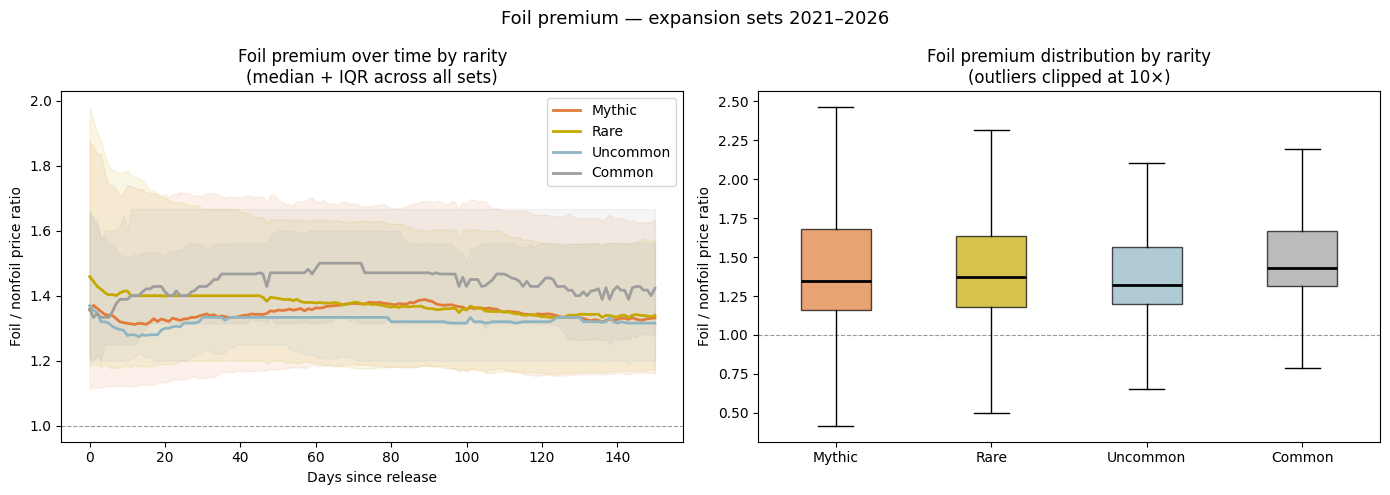

In [78]:
# Smooth premium per (set, rarity, card) then aggregate across cards
groups = []
for (set_code, rarity, card_id), g in paired.groupby(
    ["set_code", "rarity_name", "card_version_id"], sort=False
):
    g_idx = g.set_index("days_since_release").reindex(range(0, 151))
    g_idx["premium_smooth"] = g_idx["premium"].rolling(7, min_periods=3, center=True).median()
    g_idx["set_code"] = set_code
    g_idx["rarity_name"] = rarity
    groups.append(g_idx.reset_index())

paired_smooth = (
    pd.concat(groups, ignore_index=True)
    .dropna(subset=["premium"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: premium trajectory per rarity
ax = axes[0]
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
for rarity in RARITY_ORDER:
    sub = paired_smooth[paired_smooth["rarity_name"] == rarity]
    agg = sub.groupby("days_since_release")["premium_smooth"].agg(
        median="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    ax.plot(agg.index, agg["median"], color=RARITY_COLORS[rarity],
            linewidth=2, label=rarity.capitalize())
    ax.fill_between(agg.index, agg["p25"], agg["p75"],
                    color=RARITY_COLORS[rarity], alpha=0.1)
ax.set_xlabel("Days since release")
ax.set_ylabel("Foil / nonfoil price ratio")
ax.set_title("Foil premium over time by rarity\n(median + IQR across all sets)")
ax.legend()

# Right: box plot of overall premium distribution by rarity
ax = axes[1]
rarity_premiums = [
    paired[paired["rarity_name"] == r]["premium"].clip(0, 10).values
    for r in RARITY_ORDER
]
bp = ax.boxplot(rarity_premiums, labels=[r.capitalize() for r in RARITY_ORDER],
                patch_artist=True, medianprops=dict(color="black", linewidth=2),
                showfliers=False)
for patch, rarity in zip(bp["boxes"], RARITY_ORDER):
    patch.set_facecolor(RARITY_COLORS[rarity])
    patch.set_alpha(0.7)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
ax.set_ylabel("Foil / nonfoil price ratio")
ax.set_title("Foil premium distribution by rarity\n(outliers clipped at 10×)")

fig.suptitle("Foil premium — expansion sets 2021–2026", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig8_foil_premium.png", dpi=150)
plt.show()


### Figure 9 — Foil vs nonfoil correlation

Per-card correlation between daily foil and nonfoil prices. A high correlation (close to 1) means foil and nonfoil prices move together; a low correlation means they're driven by different demand.


/home/arthur/projects/AutoMana/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/arthur/projects/AutoMana/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


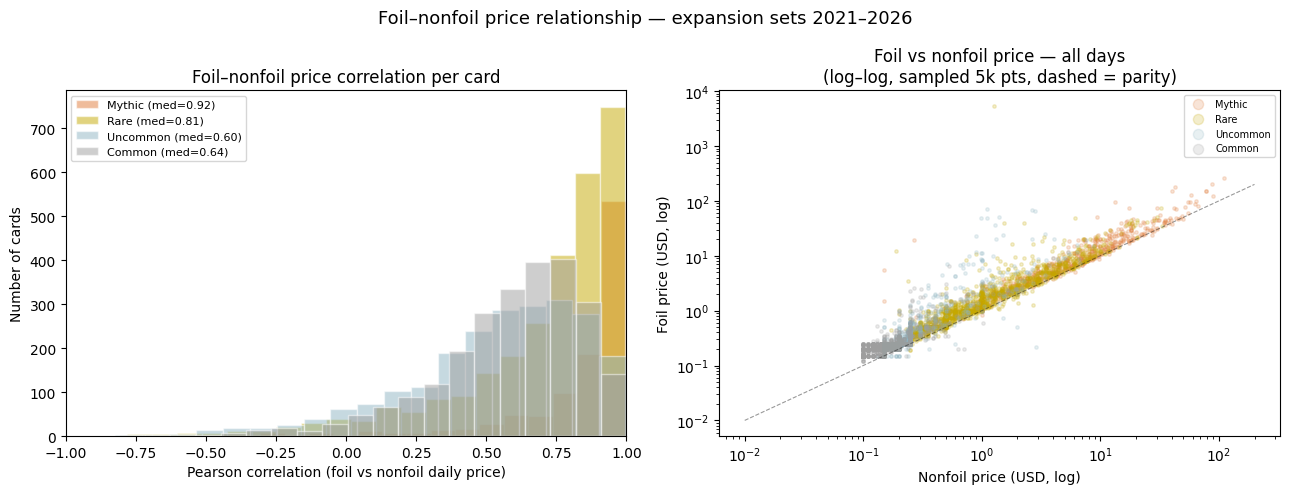

In [79]:
# Pearson correlation between foil and nonfoil daily prices, per card
card_corr = (
    paired.groupby(["set_code", "rarity_name", "card_version_id"])
    .apply(
        lambda g: g["nf_cents"].corr(g["fo_cents"]) if len(g) >= 10 else np.nan,
        include_groups=False,
    )
    .reset_index(name="corr_nf_fo")
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: correlation distribution by rarity
ax = axes[0]
for rarity in RARITY_ORDER:
    sub = card_corr[card_corr["rarity_name"] == rarity]["corr_nf_fo"]
    med = sub.median()
    ax.hist(sub, bins=20, color=RARITY_COLORS[rarity], alpha=0.5, edgecolor="white",
            label=f"{rarity.capitalize()} (med={med:.2f})")
ax.set_xlabel("Pearson correlation (foil vs nonfoil daily price)")
ax.set_ylabel("Number of cards")
ax.set_title("Foil–nonfoil price correlation per card")
ax.legend(fontsize=8)
ax.set_xlim(-1, 1)

# Right: scatter log-log nonfoil vs foil price (all days, sampled)
ax = axes[1]
all_paired_sample = paired.sample(min(5000, len(paired)), random_state=42)
for rarity in RARITY_ORDER:
    sub = all_paired_sample[all_paired_sample["rarity_name"] == rarity]
    ax.scatter(sub["nf_cents"] / 100, sub["fo_cents"] / 100,
               color=RARITY_COLORS[rarity], alpha=0.2, s=6, label=rarity.capitalize())
ax.set_xscale("log"); ax.set_yscale("log")
lims = [0.01, 200]
ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.4)  # parity line
ax.set_xlabel("Nonfoil price (USD, log)")
ax.set_ylabel("Foil price (USD, log)")
ax.set_title("Foil vs nonfoil price — all days\n(log–log, sampled 5k pts, dashed = parity)")
ax.legend(fontsize=7, markerscale=3)

fig.suptitle("Foil–nonfoil price relationship — expansion sets 2021–2026", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig9_foil_correlation.png", dpi=150)
plt.show()


### Figure 10 — Do foil and nonfoil peaks align?

For each card, we detect the peak day separately for foil and nonfoil. The difference `foil_peak_day − nonfoil_peak_day` reveals whether one finish leads the other.


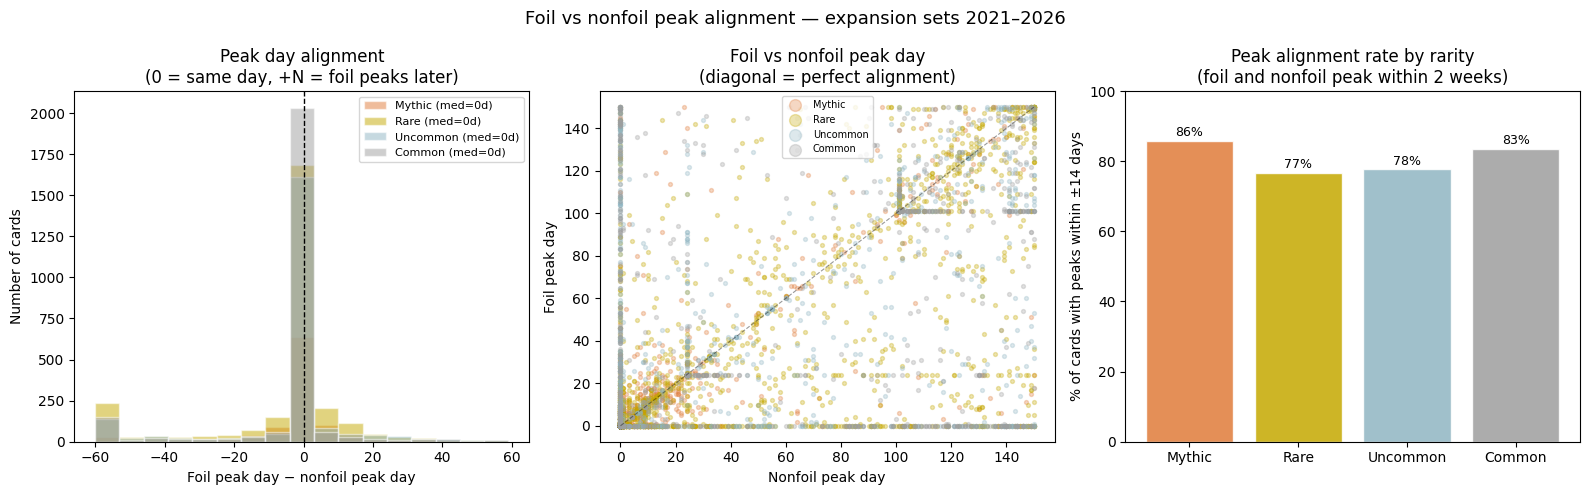


--- Peak alignment summary ---
  Mythic    : median diff = +0d, 86% of cards peak within ±14 days
  Rare      : median diff = +0d, 77% of cards peak within ±14 days
  Uncommon  : median diff = +0d, 78% of cards peak within ±14 days
  Common    : median diff = +0d, 83% of cards peak within ±14 days


In [80]:
def peak_day(series_dict):
    """Find peak day of smoothed price for foil and nonfoil paired data."""
    results = []
    for (set_code, rarity, card_id), g in paired_smooth.groupby(
        ["set_code", "rarity_name", "card_version_id"], sort=False
    ):
        g_nf = g.dropna(subset=["nf_cents"]).sort_values("days_since_release")
        g_fo = g.dropna(subset=["fo_cents"]).sort_values("days_since_release")
        if len(g_nf) < 10 or len(g_fo) < 10:
            continue

        # Smooth each finish separately
        nf_smooth = g_nf.set_index("days_since_release")["nf_cents"].rolling(7, min_periods=3, center=True).median()
        fo_smooth = g_fo.set_index("days_since_release")["fo_cents"].rolling(7, min_periods=3, center=True).median()

        results.append({
            "set_code": set_code,
            "rarity_name": rarity,
            "card_version_id": card_id,
            "nf_peak_day": nf_smooth.idxmax(),
            "fo_peak_day": fo_smooth.idxmax(),
            "nf_peak_cents": nf_smooth.max(),
            "fo_peak_cents": fo_smooth.max(),
        })
    return pd.DataFrame(results)

peak_align = peak_day({})
peak_align["peak_day_diff"] = peak_align["fo_peak_day"] - peak_align["nf_peak_day"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: distribution of peak day difference
ax = axes[0]
for rarity in RARITY_ORDER:
    sub = peak_align[peak_align["rarity_name"] == rarity]["peak_day_diff"]
    ax.hist(sub.clip(-60, 60), bins=range(-60, 65, 7),
            color=RARITY_COLORS[rarity], alpha=0.5, edgecolor="white",
            label=f"{rarity.capitalize()} (med={sub.median():.0f}d)")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Foil peak day − nonfoil peak day")
ax.set_ylabel("Number of cards")
ax.set_title("Peak day alignment\n(0 = same day, +N = foil peaks later)")
ax.legend(fontsize=8)

# Middle: scatter nonfoil peak day vs foil peak day
ax = axes[1]
for rarity in RARITY_ORDER:
    sub = peak_align[peak_align["rarity_name"] == rarity]
    ax.scatter(sub["nf_peak_day"], sub["fo_peak_day"],
               color=RARITY_COLORS[rarity], alpha=0.3, s=8, label=rarity.capitalize())
ax.plot([0, 150], [0, 150], "k--", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Nonfoil peak day")
ax.set_ylabel("Foil peak day")
ax.set_title("Foil vs nonfoil peak day\n(diagonal = perfect alignment)")
ax.legend(fontsize=7, markerscale=3)

# Right: % of cards where peaks align within ±14 days, by rarity
ax = axes[2]
aligned_pct = (
    peak_align.groupby("rarity_name")
    .apply(lambda g: (g["peak_day_diff"].abs() <= 14).mean() * 100, include_groups=False)
    .loc[RARITY_ORDER]
)
bars = ax.bar([r.capitalize() for r in RARITY_ORDER], aligned_pct,
              color=[RARITY_COLORS[r] for r in RARITY_ORDER], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, aligned_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.0f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% of cards with peaks within ±14 days")
ax.set_title("Peak alignment rate by rarity\n(foil and nonfoil peak within 2 weeks)")
ax.set_ylim(0, 100)

fig.suptitle("Foil vs nonfoil peak alignment — expansion sets 2021–2026", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig10_peak_alignment.png", dpi=150)
plt.show()

# Summary
print("\n--- Peak alignment summary ---")
for rarity in RARITY_ORDER:
    sub = peak_align[peak_align["rarity_name"] == rarity]["peak_day_diff"]
    within_14 = (sub.abs() <= 14).mean() * 100
    print(f"  {rarity.capitalize():10s}: median diff = {sub.median():+.0f}d, "
          f"{within_14:.0f}% of cards peak within ±14 days")
